Please upload your IQ-OTH/NCCD Lung Cancer Dataset zip file...


Saving lung cancer dataset - Copy (2).zip to lung cancer dataset - Copy (2).zip
Unzipping lung cancer dataset - Copy (2).zip...
Using Data Directory: lung_images/The IQ-OTHNCCD lung cancer dataset - Copy
Classes: {'Bengin cases': 0, 'Malignant cases': 1, 'Normal cases': 2}

Balancing Training Data (Oversampling)...


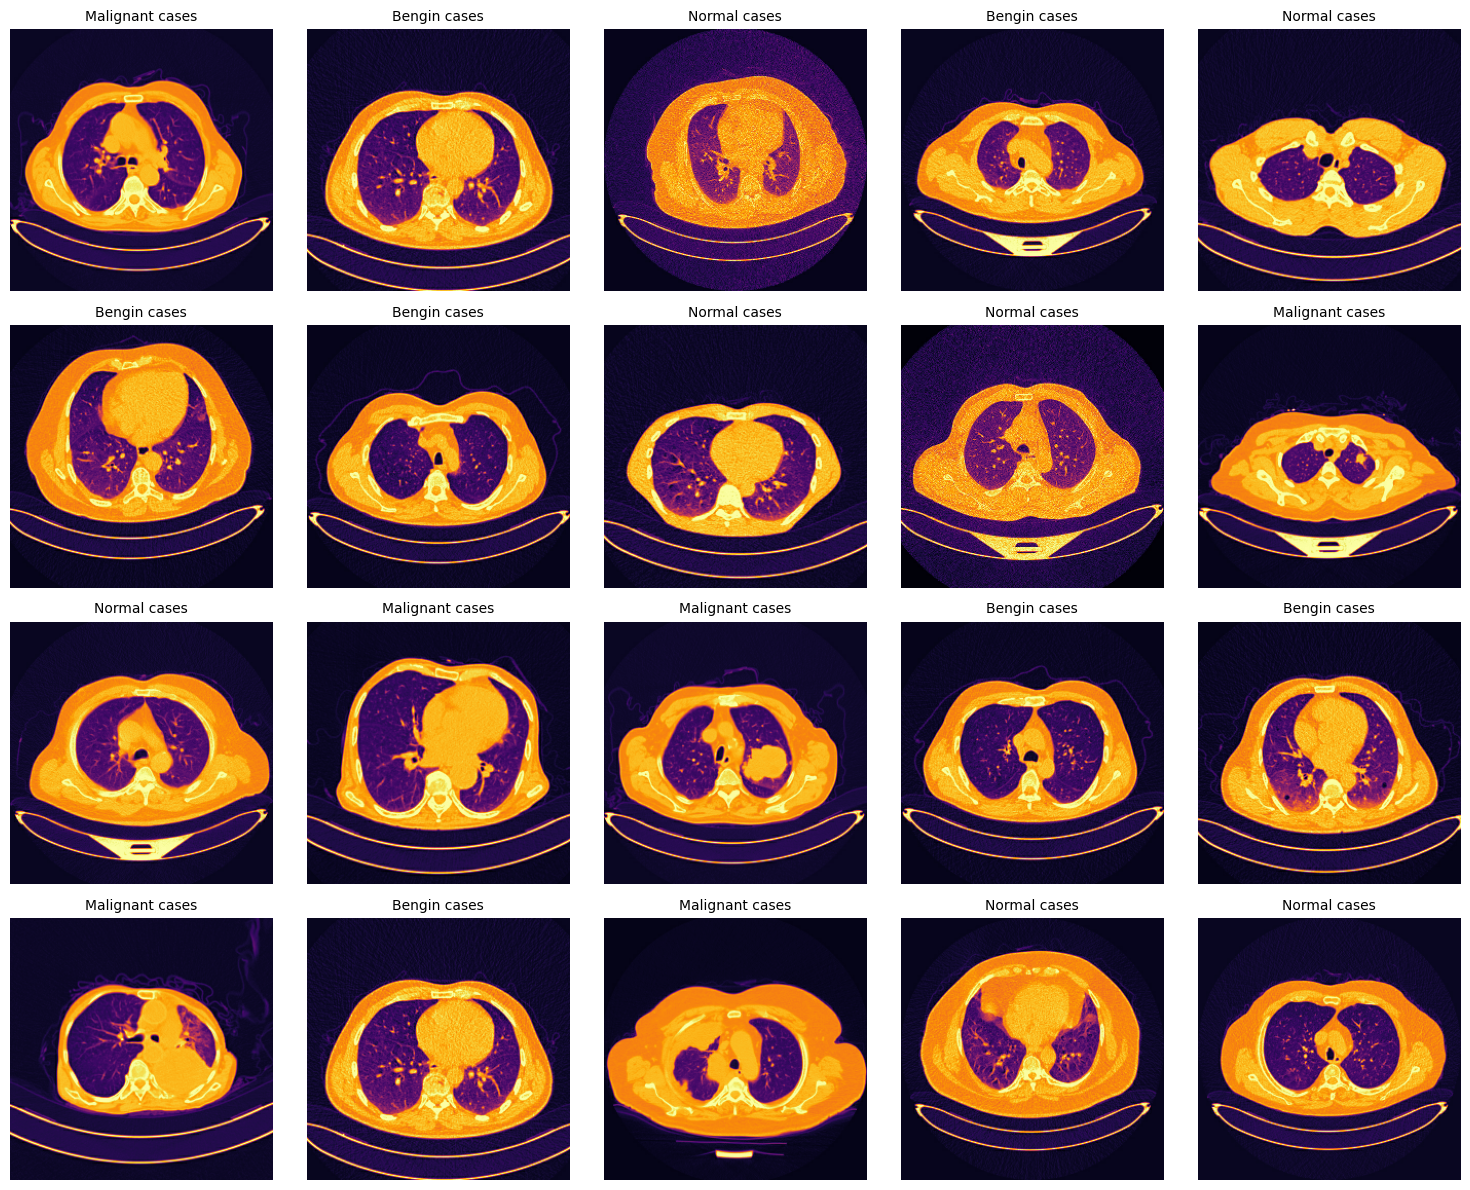

Calculating Balanced Training Distribution...


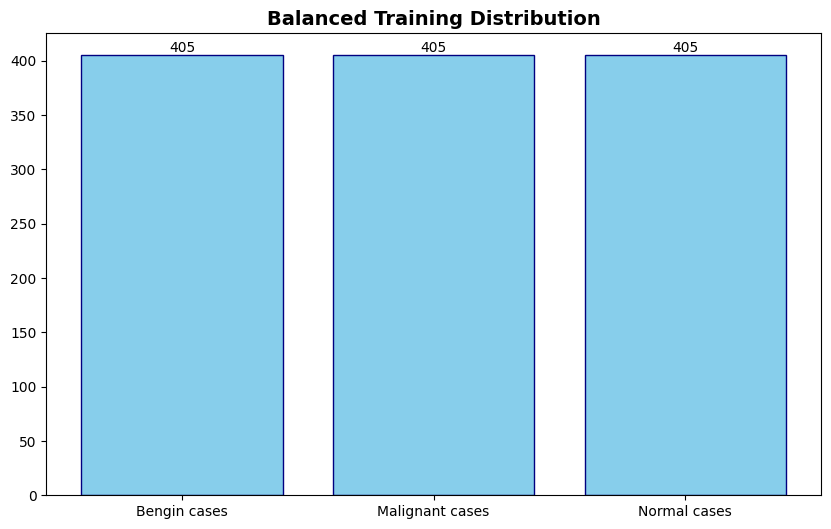


Building EM-CSA Model Architecture for Lung Cancer...


Model: "em_csa_cnn_lung"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │         80 │ rescaling[0][0]   │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      1,168 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ last_conv_layer     │ (None, 16, 16,    │     73,856 │ max_pooling2d_3[… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 8, 8, 128) │          0 │ last_conv_layer[… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ internal_sobel_calc │ (None, 8, 8, 128) │          0 │ max_pooling2d_4[… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_edge_out  │ (None, 8, 8, 128) │          0 │ internal_sobel_c… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 8, 8, 128) │          0 │ max_pooling2d_4[… │
│                     │                   │            │ attention_edge_o… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 8, 128) │          0 │ max_pooling2d_4[

 Total params: 9,974,910 (38.05 MB)

 Trainable params: 9,974,878 (38.05 MB)

 Non-trainable params: 32 (128.00 B)


Generating Model Architecture Graph...


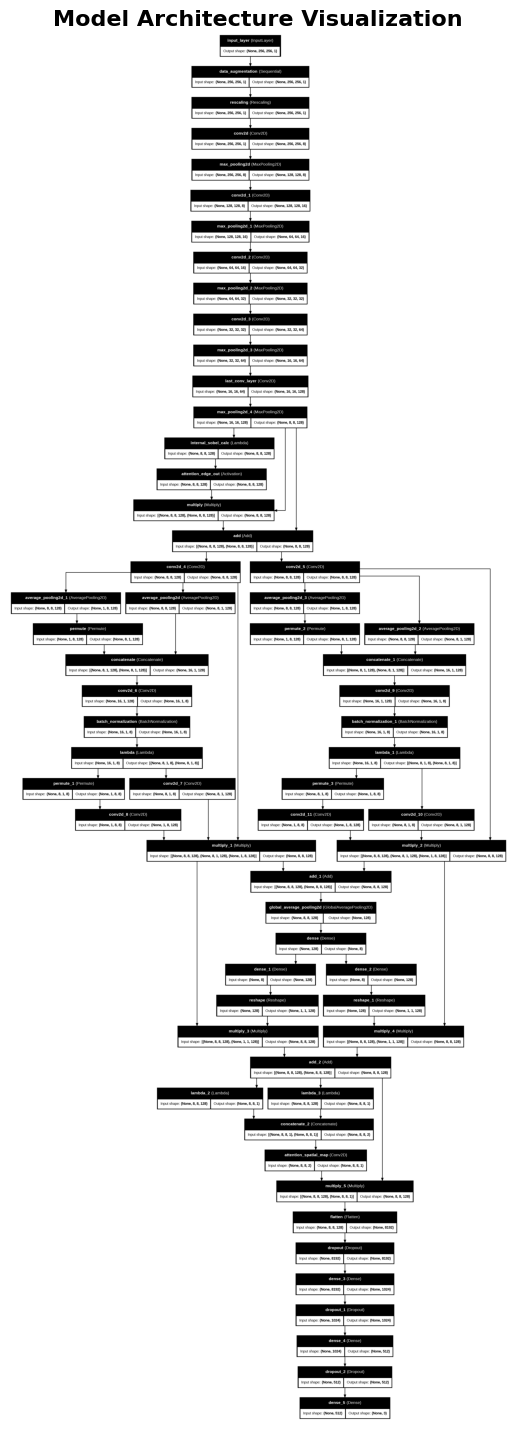


Training...


ValueError: You must call `compile()` before using the model.

In [ ]:
"""
Lung Cancer Detection (IQ-OTH/NCCD) using EM-CSA Attention & CNN
================================================================

This module implements a CNN-based system for classifying lung cancer types
(Benign, Malignant, Normal) from CT scan slices using the IQ-OTH/NCCD dataset.

It explicitly adapts the CNN logic and NOVEL Edge-Enhanced Multi-Scale
Coordinate-Spatial Attention (EM-CSA) mechanism originally designed for
Knee Arthritis and Alzheimer's detection.

Architecture Features (Inherited Logic):
- EM-CSA Attention: "Outline, Zoom, Align, Spotlight" strategy.
- Progressive feature extraction with increasing filter depth (8->128).
- Multi-scale feature fusion (3x3 and 7x7 branches).
- Dense classification head with dropout regularization.

Key Capabilities:
1. Interpretability: Grad-CAM implementation.
2. Visualization: Internal Attention Map extraction (Edge & Spatial masks).
3. Data: Automated pipeline with oversampling for class balance.
"""

import os
import shutil
import itertools
import zipfile
from collections import Counter
from typing import Tuple, Dict, Any, List
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers, backend as K
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.utils import plot_model


try:
    from google.colab import files
except ImportError:
    print("Warning: google.colab not found. Upload functionality will not work locally.")

# ==============================================================================
# NOVEL ATTENTION HELPER FUNCTIONS (GLOBAL & REGISTERED)
# ==============================================================================

@keras.utils.register_keras_serializable()
def apply_sobel(x):
    """Applies Sobel filter to input tensor to extract edges."""
    channels = x.shape[-1]
    if channels is None:
        channels = tf.shape(x)[-1]

    # Sobel Kernels
    k_x = tf.constant([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=tf.float32)
    k_x = tf.reshape(k_x, [3, 3, 1, 1])
    k_x = tf.tile(k_x, [1, 1, channels, 1])

    k_y = tf.constant([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=tf.float32)
    k_y = tf.reshape(k_y, [3, 3, 1, 1])
    k_y = tf.tile(k_y, [1, 1, channels, 1])

    edge_x = tf.nn.depthwise_conv2d(x, k_x, strides=[1, 1, 1, 1], padding='SAME')
    edge_y = tf.nn.depthwise_conv2d(x, k_y, strides=[1, 1, 1, 1], padding='SAME')

    edge_magnitude = tf.sqrt(tf.square(edge_x) + tf.square(edge_y) + 1e-6)
    return edge_magnitude

@keras.utils.register_keras_serializable()
def split_features(x, h, w):
    """Splits tensor into height and width components."""
    return tf.split(x, [h, w], axis=1)

@keras.utils.register_keras_serializable()
def global_mean_pool(x):
    return K.mean(x, axis=-1, keepdims=True)

@keras.utils.register_keras_serializable()
def global_max_pool(x):
    return K.max(x, axis=-1, keepdims=True)


# ==============================================================================
# NOVEL ATTENTION BLOCKS (EM-CSA)
# ==============================================================================

def edge_attention_block(input_tensor):
    """
    Sub-Module 1: Edge Attention (The "Outline")
    """
    # Naming layers is crucial for visualization extraction later
    edge_magnitude = layers.Lambda(apply_sobel, name="internal_sobel_calc")(input_tensor)
    edge_map = layers.Activation('sigmoid', name="attention_edge_out")(edge_magnitude)
    return layers.Add()([input_tensor, layers.Multiply()([input_tensor, edge_map])])


def coordinate_attention_part(input_tensor, ratio=32):
    """
    Sub-Module 2: Coordinate Attention (The "Align")
    """
    input_shape = K.int_shape(input_tensor)
    _, h, w, c = input_shape

    # Pool Height and Width separately
    x_pool_h = layers.AveragePooling2D(pool_size=(1, w), strides=1)(input_tensor)
    x_pool_w = layers.AveragePooling2D(pool_size=(h, 1), strides=1)(input_tensor)
    x_pool_w = layers.Permute((2, 1, 3))(x_pool_w)

    # Concatenate and Compress
    x_concat = layers.Concatenate(axis=1)([x_pool_h, x_pool_w])
    x_concat = layers.Conv2D(c // ratio, 1, activation='hard_sigmoid', padding='valid')(x_concat)
    x_concat = layers.BatchNormalization()(x_concat)

    # Split and Expand
    x_h, x_w = layers.Lambda(split_features, arguments={'h': h, 'w': w})(x_concat)
    x_w = layers.Permute((2, 1, 3))(x_w)

    x_h = layers.Conv2D(c, 1, activation='sigmoid', padding='valid')(x_h)
    x_w = layers.Conv2D(c, 1, activation='sigmoid', padding='valid')(x_w)

    return layers.Multiply()([input_tensor, x_h, x_w])


def spatial_attention_part(input_tensor):
    """
    Sub-Module 3: Spatial Attention (The "Spotlight")
    """
    avg_pool = layers.Lambda(global_mean_pool)(input_tensor)
    max_pool = layers.Lambda(global_max_pool)(input_tensor)

    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    # Named for visualization
    spatial_att = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid', name="attention_spatial_map")(concat)
    return layers.Multiply()([input_tensor, spatial_att])


def em_csa_block(input_tensor, filters, ratio=16):
    """
    MAIN NOVEL BLOCK: Edge-Enhanced Multi-Scale Coordinate-Spatial Attention
    """
    # --- PHASE 1: OUTLINE ---
    x_edged = edge_attention_block(input_tensor)

    # --- PHASE 2: ZOOM (Multi-Scale Split) ---
    xs_1 = layers.Conv2D(filters, kernel_size=3, padding='same', activation='relu')(x_edged)
    xs_2 = layers.Conv2D(filters, kernel_size=7, padding='same', activation='relu')(x_edged)

    # --- PHASE 3: ALIGN (Coordinate Attention) ---
    xs_1 = coordinate_attention_part(xs_1, ratio=ratio)
    xs_2 = coordinate_attention_part(xs_2, ratio=ratio)

    # --- FUSION (Adaptive Selection) ---
    u = layers.Add()([xs_1, xs_2])
    s = layers.GlobalAveragePooling2D()(u)
    z = layers.Dense(filters // ratio, activation='relu')(s)

    attn_1 = layers.Dense(filters, activation='softmax')(z)
    attn_2 = layers.Dense(filters, activation='softmax')(z)

    attn_1 = layers.Reshape((1, 1, filters))(attn_1)
    attn_2 = layers.Reshape((1, 1, filters))(attn_2)

    fused = layers.Add()([
        layers.Multiply()([xs_1, attn_1]),
        layers.Multiply()([xs_2, attn_2])
    ])

    # --- PHASE 4: SPOTLIGHT (Spatial Attention) ---
    output = spatial_attention_part(fused)

    return output


# ==============================================================================
# Model Construction (EM-CSA Architecture)
# ==============================================================================

def build_em_csa_model(input_shape: Tuple[int, int, int] = (256, 256, 1),
                       num_classes: int = 3,
                       use_dense_layers: bool = True) -> keras.Model:
    """
    Constructs CNN with EM-CSA Attention for Lung Cancer classification.
    """
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ], name="data_augmentation")

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    # Progressive Feature Extraction
    x = layers.Conv2D(8, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(16, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2)(x)

    # Last Conv Block before Attention - We name this for GradCAM targeting
    x = layers.Conv2D(128, 3, activation="relu", padding="same", name="last_conv_layer")(x)
    x = layers.MaxPooling2D(2)(x)

    # ==========================================================================
    # NOVEL ATTENTION INTEGRATION (EM-CSA)
    # ==========================================================================
    x = em_csa_block(x, filters=128, ratio=16)

    # Classification head
    x = layers.Flatten()(x)

    if use_dense_layers:
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(1024, activation="relu")(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(512, activation="relu")(x)
        x = layers.Dropout(0.2)(x)
    else:
        x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model_name = "em_csa_cnn_lung"
    return keras.Model(inputs, outputs, name=model_name)


# ==============================================================================
# Visualization Engine (GradCAM & Attention Maps)
# ==============================================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Computes Grad-CAM heatmap for a specific class.
    """
    grad_model = keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


def visualize_internal_attention_and_gradcam(model, img_path, image_size, class_names):
    """
    Generates a comprehensive visualization panel:
    1. Original Image
    2. Edge Attention Map (The "Outline")
    3. Spatial Attention Map (The "Spotlight")
    4. Grad-CAM (The "Decision")
    """
    img = keras.utils.load_img(img_path, target_size=image_size, color_mode='grayscale')
    img_array = keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    # --- 1. Get Predictions ---
    preds = model.predict(img_batch, verbose=0)
    pred_idx = np.argmax(preds)
    pred_label = class_names[pred_idx]
    confidence = np.max(preds) * 100

    # --- 2. Extract Internal Attention Maps ---
    try:
        layer_edge = model.get_layer("attention_edge_out")
        layer_spatial = model.get_layer("attention_spatial_map")

        intermediate_model = keras.models.Model(
            inputs=model.inputs,
            outputs=[layer_edge.output, layer_spatial.output]
        )
        edge_map, spatial_map = intermediate_model.predict(img_batch, verbose=0)

        edge_vis = np.mean(edge_map[0], axis=-1)
        spatial_vis = np.mean(spatial_map[0], axis=-1)

    except ValueError as e:
        print(f"Could not extract internal attention layers: {e}")
        return

    # --- 3. Compute Grad-CAM ---
    try:
        heatmap = make_gradcam_heatmap(img_batch, model, "last_conv_layer")
    except Exception as e:
        print(f"GradCAM computation failed: {e}")
        heatmap = np.zeros(image_size)

    # --- 4. Plotting ---
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # A. Original
    axes[0].imshow(img_array.squeeze(), cmap='gray')
    axes[0].set_title(f"Input: {pred_label}\nConf: {confidence:.1f}%")
    axes[0].axis('off')

    # B. Edge Attention (Outline)
    import cv2
    edge_vis_resized = cv2.resize(edge_vis, image_size)
    axes[1].imshow(img_array.squeeze(), cmap='gray')
    axes[1].imshow(edge_vis_resized, cmap='jet', alpha=0.5)
    axes[1].set_title("EM-CSA: Edge (Outline)")
    axes[1].axis('off')

    # C. Spatial Attention (Spotlight)
    spatial_vis_resized = cv2.resize(spatial_vis, image_size)
    axes[2].imshow(img_array.squeeze(), cmap='gray')
    axes[2].imshow(spatial_vis_resized, cmap='inferno', alpha=0.6)
    axes[2].set_title("EM-CSA: Spatial (Spotlight)")
    axes[2].axis('off')

    # D. Grad-CAM
    heatmap_uint8 = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]

    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize(image_size)
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * 0.4 + img_array
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    axes[3].imshow(superimposed_img)
    axes[3].set_title("Grad-CAM (Final Decision)")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()


# ==============================================================================
# DATA LOADING & UTILS
# ==============================================================================

def create_dataset_from_paths(file_paths, labels, image_size=(256, 256), num_classes=3):
    """Creates a tf.data.Dataset from file paths and labels."""
    def process_path(file_path, label):
        img = tf.io.read_file(file_path)
        img = tf.image.decode_jpeg(img, channels=1)
        img = tf.image.resize(img, image_size)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    return ds

def visualize_samples(dataset, class_names: List[str], num_samples: int = 20):
    """Visualizes sample images from dataset."""
    dataset_preview = dataset.take(num_samples)
    plt.figure(figsize=(15, 12))
    for i, (image, label) in enumerate(dataset_preview):
        plt.subplot(4, 5, i + 1)
        plt.imshow(image.numpy().astype("uint8").squeeze(), cmap="inferno")
        label_idx = label.numpy().astype('uint8')
        label_text = class_names[label_idx] if label_idx < len(class_names) else f"Class {label_idx}"
        plt.title(f"{label_text}", fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def plot_class_distribution(dataset, class_names: List[str], title: str = "Class Distribution"):
    print(f"Calculating {title}...")
    counts = {name: 0 for name in class_names}
    for _, label in dataset:
        idx = int(label.numpy())
        if idx < len(class_names):
            counts[class_names[idx]] += 1

    labels = list(counts.keys())
    values = list(counts.values())
    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, values, color='skyblue', edgecolor='navy')
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height, f'{height}', ha='center', va='bottom')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.show()

def plot_confusion_matrix_custom(model, dataset, class_names):
    print("Generating Confusion Matrix predictions...")
    batched_ds = dataset.batch(32)
    all_preds = []
    all_labels = []
    for images, labels in batched_ds:
        preds = model.predict(images, verbose=0)
        all_preds.extend(np.argmax(preds, axis=1))
        all_labels.extend(labels.numpy().astype(int))

    cm_mat = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm_mat, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    thresh = cm_mat.max() / 2.
    for i, j in itertools.product(range(cm_mat.shape[0]), range(cm_mat.shape[1])):
        plt.text(j, i, format(cm_mat[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm_mat[i, j] > thresh else "black")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

def plot_training_history(history, save_path=None):
    epochs = range(1, len(history["accuracy"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs, history["accuracy"], "b-", label="Training")
    ax1.plot(epochs, history["val_accuracy"], "r-", label="Validation")
    ax1.set_title("Model Accuracy")
    ax1.legend()
    ax2.plot(epochs, history["loss"], "b-", label="Training")
    ax2.plot(epochs, history["val_loss"], "r-", label="Validation")
    ax2.set_title("Model Loss")
    ax2.legend()
    plt.tight_layout()
    plt.show()

def plot_model_architecture(model: keras.Model, save_path: str = 'model_architecture.png') -> None:
    """Plots the model architecture as a graph and displays it."""
    print("\nGenerating Model Architecture Graph...")
    try:
        plot_model(model, to_file=save_path, show_shapes=True, show_layer_names=True, dpi=96)
        img = plt.imread(save_path)
        plt.figure(figsize=(12, 18))
        plt.imshow(img)
        plt.axis('off')
        plt.title("Model Architecture Visualization", fontsize=16, fontweight='bold')
        plt.show()
    except Exception as e:
        print(f"Could not plot model architecture (Graphviz/Pydot may be missing): {e}")

def predict_custom_image(model: keras.Model, class_names: List[str], image_size: Tuple[int, int] = (256, 256)):
    """Allows user to upload an image file (in Colab) and predicts the class."""
    print("\n" + "="*50)
    print("CUSTOM IMAGE PREDICTION")
    print("="*50)
    print("Please upload a CT Scan image for analysis...")

    try:
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            print("No file uploaded.")
            return

        for filename in uploaded.keys():
            print(f"\nProcessing {filename}...")
            img = keras.utils.load_img(filename, target_size=image_size, color_mode='grayscale')
            img_array = keras.utils.img_to_array(img)
            img_batch = np.expand_dims(img_array, axis=0)

            prediction = model.predict(img_batch, verbose=0)
            predicted_idx = np.argmax(prediction)
            confidence = np.max(prediction) * 100
            predicted_label = class_names[predicted_idx] if predicted_idx < len(class_names) else f"Class {predicted_idx}"

            plt.figure(figsize=(6, 6))
            plt.imshow(img_array.squeeze(), cmap='gray')
            plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%", fontsize=14, fontweight='bold')
            plt.axis('off')
            plt.show()

            # Optional: Visualize Attention for this custom image
            print("Generating attention maps for custom image...")
            visualize_internal_attention_and_gradcam(model, filename, image_size, class_names)

    except ImportError:
        print("Google Colab environment not detected. Skipping custom upload feature.")
    except Exception as e:
        print(f"Error processing custom image: {e}")


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

def main():
    IMAGE_SIZE = (256, 256)
    NUM_CLASSES = 3  # IQ-OTH/NCCD: Benign, Malignant, Normal
    BATCH_SIZE = 16
    EPOCHS = 50

    # 1. Upload & Unzip
    print("Please upload your IQ-OTH/NCCD Lung Cancer Dataset zip file...")
    try:
        from google.colab import files
        uploaded = files.upload()
        if uploaded:
            zip_name = list(uploaded.keys())[0]
            print(f"Unzipping {zip_name}...")
            os.system(f'unzip -q "{zip_name}" -d lung_images')

            # Find data dir
            DATA_DIR = "lung_images"
            for root, dirs, _ in os.walk("lung_images"):
                if len(dirs) > 1 and "Data" not in root:
                     DATA_DIR = root
                     break
            print(f"Using Data Directory: {DATA_DIR}")
        else:
            print("No file uploaded.")
            return
    except Exception as e:
        print(f"Error handling zip: {e}")
        return

    # 2. Parse paths & labels
    file_paths, labels = [], []
    detected_classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
    class_to_idx = {name: i for i, name in enumerate(detected_classes)}

    print(f"Classes: {class_to_idx}")

    for label_name in detected_classes:
        class_dir = os.path.join(DATA_DIR, label_name)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_paths.append(os.path.join(class_dir, fname))
                labels.append(class_to_idx[label_name])

    if not file_paths:
        print("No images found.")
        return

    # 3. Split & Oversample (Logic inherited from Alzheimer's code)
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        file_paths, labels, test_size=0.15, stratify=labels, random_state=42
    )
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_val_paths, train_val_labels, test_size=0.15, stratify=train_val_labels, random_state=42
    )

    print("\nBalancing Training Data (Oversampling)...")
    max_count = max(Counter(train_labels).values())
    balanced_train_paths, balanced_train_labels = [], []

    for cls in range(NUM_CLASSES):
        cls_paths = [p for p, l in zip(train_paths, train_labels) if l == cls]
        if cls_paths:
            resampled = np.random.choice(cls_paths, max_count, replace=True)
            balanced_train_paths.extend(resampled)
            balanced_train_labels.extend([cls] * max_count)

    # Shuffle
    shuffle_idx = np.random.permutation(len(balanced_train_paths))
    train_paths = np.array(balanced_train_paths)[shuffle_idx].tolist()
    train_labels = np.array(balanced_train_labels)[shuffle_idx].tolist()

    # 4. Create Datasets
    train_ds = create_dataset_from_paths(train_paths, train_labels, IMAGE_SIZE, NUM_CLASSES)
    val_ds = create_dataset_from_paths(val_paths, val_labels, IMAGE_SIZE, NUM_CLASSES)
    test_ds = create_dataset_from_paths(test_paths, test_labels, IMAGE_SIZE, NUM_CLASSES)

    class_names = detected_classes if detected_classes else [str(i) for i in range(NUM_CLASSES)]

    # 5. Visualize Input
    visualize_samples(train_ds, class_names)
    plot_class_distribution(train_ds, class_names, title="Balanced Training Distribution")

    # 6. Build EM-CSA Model
    print("\nBuilding EM-CSA Model Architecture for Lung Cancer...")
    model = build_em_csa_model(input_shape=(*IMAGE_SIZE, 1), num_classes=NUM_CLASSES)
    model.summary()

    plot_model_architecture(model)

    # 7. Train
    print("\nTraining...")
    train_batched = train_ds.batch(BATCH_SIZE)
    val_batched = val_ds.batch(BATCH_SIZE)

    checkpoint = keras.callbacks.ModelCheckpoint(
        "best_lung_model.h5", save_best_only=True, monitor="val_accuracy", mode="max", verbose=1
    )

    history = model.fit(
        train_batched, epochs=EPOCHS, validation_data=val_batched, callbacks=[checkpoint], verbose=1
    )

    plot_training_history(history.history)

    # 8. Evaluate
    print("\nLoading best model...")
    best_model = keras.models.load_model("best_lung_model.h5")

    test_loss, test_acc = best_model.evaluate(test_ds.batch(32))
    print(f"Test Accuracy: {test_acc*100:.2f}%")

    plot_confusion_matrix_custom(best_model, test_ds, class_names)

    # 9. ADVANCED VISUALIZATION (GradCAM + Attention Maps)
    print("\n" + "="*50)
    print("GENERATING ADVANCED ATTENTION VISUALIZATION")
    print("="*50)

    # Pick random samples from test set for deep visualization
    # We take 3 samples to visualize
    random_indices = np.random.choice(len(test_paths), 3, replace=False)
    for idx in random_indices:
        print(f"\nVisualizing Test Sample Index: {idx}")
        path = test_paths[idx]
        true_label = class_names[test_labels[idx]]
        print(f"True Label: {true_label}")

        visualize_internal_attention_and_gradcam(best_model, path, IMAGE_SIZE, class_names)

    # 10. Custom Image Upload
    predict_custom_image(best_model, class_names, IMAGE_SIZE)

if __name__ == "__main__":
    main()

In [ ]:
"""
Lung Cancer Detection (IQ-OTH/NCCD) using EM-CSA Attention & CNN
================================================================

This module implements a CNN-based system for classifying lung cancer types
(Benign, Malignant, Normal) from CT scan slices using the IQ-OTH/NCCD dataset.

It explicitly adapts the CNN logic and NOVEL Edge-Enhanced Multi-Scale
Coordinate-Spatial Attention (EM-CSA) mechanism originally designed for
Knee Arthritis and Alzheimer's detection.

Architecture Features (Inherited Logic):
- EM-CSA Attention: "Outline, Zoom, Align, Spotlight" strategy.
- Progressive feature extraction with increasing filter depth (8->128).
- Multi-scale feature fusion (3x3 and 7x7 branches).
- Dense classification head with dropout regularization.

Key Capabilities:
1. Interpretability: Grad-CAM implementation.
2. Visualization: Internal Attention Map extraction (Edge & Spatial masks).
3. Data: Automated pipeline with oversampling for class balance.
"""

import os
import shutil
import itertools
import zipfile
from collections import Counter
from typing import Tuple, Dict, Any, List
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers, backend as K
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.utils import plot_model


try:
    from google.colab import files
except ImportError:
    print("Warning: google.colab not found. Upload functionality will not work locally.")

# ==============================================================================
# NOVEL ATTENTION HELPER FUNCTIONS (GLOBAL & REGISTERED)
# ==============================================================================

@keras.utils.register_keras_serializable()
def apply_sobel(x):
    """Applies Sobel filter to input tensor to extract edges."""
    channels = x.shape[-1]
    if channels is None:
        channels = tf.shape(x)[-1]

    # Sobel Kernels
    k_x = tf.constant([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=tf.float32)
    k_x = tf.reshape(k_x, [3, 3, 1, 1])
    k_x = tf.tile(k_x, [1, 1, channels, 1])

    k_y = tf.constant([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=tf.float32)
    k_y = tf.reshape(k_y, [3, 3, 1, 1])
    k_y = tf.tile(k_y, [1, 1, channels, 1])

    edge_x = tf.nn.depthwise_conv2d(x, k_x, strides=[1, 1, 1, 1], padding='SAME')
    edge_y = tf.nn.depthwise_conv2d(x, k_y, strides=[1, 1, 1, 1], padding='SAME')

    edge_magnitude = tf.sqrt(tf.square(edge_x) + tf.square(edge_y) + 1e-6)
    return edge_magnitude

@keras.utils.register_keras_serializable()
def split_features(x, h, w):
    """Splits tensor into height and width components."""
    return tf.split(x, [h, w], axis=1)

@keras.utils.register_keras_serializable()
def global_mean_pool(x):
    return K.mean(x, axis=-1, keepdims=True)

@keras.utils.register_keras_serializable()
def global_max_pool(x):
    return K.max(x, axis=-1, keepdims=True)


# ==============================================================================
# NOVEL ATTENTION BLOCKS (EM-CSA)
# ==============================================================================

def edge_attention_block(input_tensor):
    """
    Sub-Module 1: Edge Attention (The "Outline")
    """
    # Naming layers is crucial for visualization extraction later
    edge_magnitude = layers.Lambda(apply_sobel, name="internal_sobel_calc")(input_tensor)
    edge_map = layers.Activation('sigmoid', name="attention_edge_out")(edge_magnitude)
    return layers.Add()([input_tensor, layers.Multiply()([input_tensor, edge_map])])


def coordinate_attention_part(input_tensor, ratio=32):
    """
    Sub-Module 2: Coordinate Attention (The "Align")
    """
    input_shape = K.int_shape(input_tensor)
    _, h, w, c = input_shape

    # Pool Height and Width separately
    x_pool_h = layers.AveragePooling2D(pool_size=(1, w), strides=1)(input_tensor)
    x_pool_w = layers.AveragePooling2D(pool_size=(h, 1), strides=1)(input_tensor)
    x_pool_w = layers.Permute((2, 1, 3))(x_pool_w)

    # Concatenate and Compress
    x_concat = layers.Concatenate(axis=1)([x_pool_h, x_pool_w])
    x_concat = layers.Conv2D(c // ratio, 1, activation='hard_sigmoid', padding='valid')(x_concat)
    x_concat = layers.BatchNormalization()(x_concat)

    # Split and Expand
    x_h, x_w = layers.Lambda(split_features, arguments={'h': h, 'w': w})(x_concat)
    x_w = layers.Permute((2, 1, 3))(x_w)

    x_h = layers.Conv2D(c, 1, activation='sigmoid', padding='valid')(x_h)
    x_w = layers.Conv2D(c, 1, activation='sigmoid', padding='valid')(x_w)

    return layers.Multiply()([input_tensor, x_h, x_w])


def spatial_attention_part(input_tensor):
    """
    Sub-Module 3: Spatial Attention (The "Spotlight")
    """
    avg_pool = layers.Lambda(global_mean_pool)(input_tensor)
    max_pool = layers.Lambda(global_max_pool)(input_tensor)

    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    # Named for visualization
    spatial_att = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid', name="attention_spatial_map")(concat)
    return layers.Multiply()([input_tensor, spatial_att])


def em_csa_block(input_tensor, filters, ratio=16):
    """
    MAIN NOVEL BLOCK: Edge-Enhanced Multi-Scale Coordinate-Spatial Attention
    """
    # --- PHASE 1: OUTLINE ---
    x_edged = edge_attention_block(input_tensor)

    # --- PHASE 2: ZOOM (Multi-Scale Split) ---
    xs_1 = layers.Conv2D(filters, kernel_size=3, padding='same', activation='relu')(x_edged)
    xs_2 = layers.Conv2D(filters, kernel_size=7, padding='same', activation='relu')(x_edged)

    # --- PHASE 3: ALIGN (Coordinate Attention) ---
    xs_1 = coordinate_attention_part(xs_1, ratio=ratio)
    xs_2 = coordinate_attention_part(xs_2, ratio=ratio)

    # --- FUSION (Adaptive Selection) ---
    u = layers.Add()([xs_1, xs_2])
    s = layers.GlobalAveragePooling2D()(u)
    z = layers.Dense(filters // ratio, activation='relu')(s)

    attn_1 = layers.Dense(filters, activation='softmax')(z)
    attn_2 = layers.Dense(filters, activation='softmax')(z)

    attn_1 = layers.Reshape((1, 1, filters))(attn_1)
    attn_2 = layers.Reshape((1, 1, filters))(attn_2)

    fused = layers.Add()([
        layers.Multiply()([xs_1, attn_1]),
        layers.Multiply()([xs_2, attn_2])
    ])

    # --- PHASE 4: SPOTLIGHT (Spatial Attention) ---
    output = spatial_attention_part(fused)

    return output


# ==============================================================================
# Model Construction (EM-CSA Architecture)
# ==============================================================================

def build_em_csa_model(input_shape: Tuple[int, int, int] = (256, 256, 1),
                       num_classes: int = 3,
                       use_dense_layers: bool = True) -> keras.Model:
    """
    Constructs CNN with EM-CSA Attention for Lung Cancer classification.
    """
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ], name="data_augmentation")

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    # Progressive Feature Extraction
    x = layers.Conv2D(8, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(16, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2)(x)

    # Last Conv Block before Attention - We name this for GradCAM targeting
    x = layers.Conv2D(128, 3, activation="relu", padding="same", name="last_conv_layer")(x)
    x = layers.MaxPooling2D(2)(x)

    # ==========================================================================
    # NOVEL ATTENTION INTEGRATION (EM-CSA)
    # ==========================================================================
    x = em_csa_block(x, filters=128, ratio=16)

    # Classification head
    x = layers.Flatten()(x)

    if use_dense_layers:
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(1024, activation="relu")(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(512, activation="relu")(x)
        x = layers.Dropout(0.2)(x)
    else:
        x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model_name = "em_csa_cnn_lung"
    return keras.Model(inputs, outputs, name=model_name)


# ==============================================================================
# Visualization Engine (GradCAM & Attention Maps)
# ==============================================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Computes Grad-CAM heatmap for a specific class.
    """
    grad_model = keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


def visualize_internal_attention_and_gradcam(model, img_path, image_size, class_names):
    """
    Generates a comprehensive visualization panel:
    1. Original Image
    2. Edge Attention Map (The "Outline")
    3. Spatial Attention Map (The "Spotlight")
    4. Grad-CAM (The "Decision")
    """
    img = keras.utils.load_img(img_path, target_size=image_size, color_mode='grayscale')
    img_array = keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    # --- 1. Get Predictions ---
    preds = model.predict(img_batch, verbose=0)
    pred_idx = np.argmax(preds)
    pred_label = class_names[pred_idx]
    confidence = np.max(preds) * 100

    # --- 2. Extract Internal Attention Maps ---
    try:
        layer_edge = model.get_layer("attention_edge_out")
        layer_spatial = model.get_layer("attention_spatial_map")

        intermediate_model = keras.models.Model(
            inputs=model.inputs,
            outputs=[layer_edge.output, layer_spatial.output]
        )
        edge_map, spatial_map = intermediate_model.predict(img_batch, verbose=0)

        edge_vis = np.mean(edge_map[0], axis=-1)
        spatial_vis = np.mean(spatial_map[0], axis=-1)

    except ValueError as e:
        print(f"Could not extract internal attention layers: {e}")
        return

    # --- 3. Compute Grad-CAM ---
    try:
        heatmap = make_gradcam_heatmap(img_batch, model, "last_conv_layer")
    except Exception as e:
        print(f"GradCAM computation failed: {e}")
        heatmap = np.zeros(image_size)

    # --- 4. Plotting ---
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # A. Original
    axes[0].imshow(img_array.squeeze(), cmap='gray')
    axes[0].set_title(f"Input: {pred_label}\nConf: {confidence:.1f}%")
    axes[0].axis('off')

    # B. Edge Attention (Outline)
    import cv2
    edge_vis_resized = cv2.resize(edge_vis, image_size)
    axes[1].imshow(img_array.squeeze(), cmap='gray')
    axes[1].imshow(edge_vis_resized, cmap='jet', alpha=0.5)
    axes[1].set_title("EM-CSA: Edge (Outline)")
    axes[1].axis('off')

    # C. Spatial Attention (Spotlight)
    spatial_vis_resized = cv2.resize(spatial_vis, image_size)
    axes[2].imshow(img_array.squeeze(), cmap='gray')
    axes[2].imshow(spatial_vis_resized, cmap='inferno', alpha=0.6)
    axes[2].set_title("EM-CSA: Spatial (Spotlight)")
    axes[2].axis('off')

    # D. Grad-CAM
    heatmap_uint8 = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]

    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize(image_size)
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * 0.4 + img_array
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    axes[3].imshow(superimposed_img)
    axes[3].set_title("Grad-CAM (Final Decision)")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()


# ==============================================================================
# DATA LOADING & UTILS
# ==============================================================================

def create_dataset_from_paths(file_paths, labels, image_size=(256, 256), num_classes=3):
    """Creates a tf.data.Dataset from file paths and labels."""
    def process_path(file_path, label):
        img = tf.io.read_file(file_path)
        img = tf.image.decode_jpeg(img, channels=1)
        img = tf.image.resize(img, image_size)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    return ds

def visualize_samples(dataset, class_names: List[str], num_samples: int = 20):
    """Visualizes sample images from dataset."""
    dataset_preview = dataset.take(num_samples)
    plt.figure(figsize=(15, 12))
    for i, (image, label) in enumerate(dataset_preview):
        plt.subplot(4, 5, i + 1)
        plt.imshow(image.numpy().astype("uint8").squeeze(), cmap="inferno")
        label_idx = label.numpy().astype('uint8')
        label_text = class_names[label_idx] if label_idx < len(class_names) else f"Class {label_idx}"
        plt.title(f"{label_text}", fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def plot_class_distribution(dataset, class_names: List[str], title: str = "Class Distribution"):
    print(f"Calculating {title}...")
    counts = {name: 0 for name in class_names}
    for _, label in dataset:
        idx = int(label.numpy())
        if idx < len(class_names):
            counts[class_names[idx]] += 1

    labels = list(counts.keys())
    values = list(counts.values())
    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, values, color='skyblue', edgecolor='navy')
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height, f'{height}', ha='center', va='bottom')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.show()

def plot_confusion_matrix_custom(model, dataset, class_names):
    print("Generating Confusion Matrix predictions...")
    batched_ds = dataset.batch(32)
    all_preds = []
    all_labels = []
    for images, labels in batched_ds:
        preds = model.predict(images, verbose=0)
        all_preds.extend(np.argmax(preds, axis=1))
        all_labels.extend(labels.numpy().astype(int))

    cm_mat = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm_mat, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    thresh = cm_mat.max() / 2.
    for i, j in itertools.product(range(cm_mat.shape[0]), range(cm_mat.shape[1])):
        plt.text(j, i, format(cm_mat[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm_mat[i, j] > thresh else "black")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

def plot_training_history(history, save_path=None):
    epochs = range(1, len(history["accuracy"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs, history["accuracy"], "b-", label="Training")
    ax1.plot(epochs, history["val_accuracy"], "r-", label="Validation")
    ax1.set_title("Model Accuracy")
    ax1.legend()
    ax2.plot(epochs, history["loss"], "b-", label="Training")
    ax2.plot(epochs, history["val_loss"], "r-", label="Validation")
    ax2.set_title("Model Loss")
    ax2.legend()
    plt.tight_layout()
    plt.show()

def plot_model_architecture(model: keras.Model, save_path: str = 'model_architecture.png') -> None:
    """Plots the model architecture as a graph and displays it."""
    print("\nGenerating Model Architecture Graph...")
    try:
        plot_model(model, to_file=save_path, show_shapes=True, show_layer_names=True, dpi=96)
        img = plt.imread(save_path)
        plt.figure(figsize=(12, 18))
        plt.imshow(img)
        plt.axis('off')
        plt.title("Model Architecture Visualization", fontsize=16, fontweight='bold')
        plt.show()
    except Exception as e:
        print(f"Could not plot model architecture (Graphviz/Pydot may be missing): {e}")

def predict_custom_image(model: keras.Model, class_names: List[str], image_size: Tuple[int, int] = (256, 256)):
    """Allows user to upload an image file (in Colab) and predicts the class."""
    print("\n" + "="*50)
    print("CUSTOM IMAGE PREDICTION")
    print("="*50)
    print("Please upload a CT Scan image for analysis...")

    try:
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            print("No file uploaded.")
            return

        for filename in uploaded.keys():
            print(f"\nProcessing {filename}...")
            img = keras.utils.load_img(filename, target_size=image_size, color_mode='grayscale')
            img_array = keras.utils.img_to_array(img)
            img_batch = np.expand_dims(img_array, axis=0)

            prediction = model.predict(img_batch, verbose=0)
            predicted_idx = np.argmax(prediction)
            confidence = np.max(prediction) * 100
            predicted_label = class_names[predicted_idx] if predicted_idx < len(class_names) else f"Class {predicted_idx}"

            plt.figure(figsize=(6, 6))
            plt.imshow(img_array.squeeze(), cmap='gray')
            plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%", fontsize=14, fontweight='bold')
            plt.axis('off')
            plt.show()

            # Optional: Visualize Attention for this custom image
            print("Generating attention maps for custom image...")
            visualize_internal_attention_and_gradcam(model, filename, image_size, class_names)

    except ImportError:
        print("Google Colab environment not detected. Skipping custom upload feature.")
    except Exception as e:
        print(f"Error processing custom image: {e}")


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

def main():
    IMAGE_SIZE = (256, 256)
    NUM_CLASSES = 3  # IQ-OTH/NCCD: Benign, Malignant, Normal
    BATCH_SIZE = 16
    EPOCHS = 50

    # 1. Upload & Unzip
    print("Please upload your IQ-OTH/NCCD Lung Cancer Dataset zip file...")
    try:
        from google.colab import files
        uploaded = files.upload()
        if uploaded:
            zip_name = list(uploaded.keys())[0]
            print(f"Unzipping {zip_name}...")
            os.system(f'unzip -q "{zip_name}" -d lung_images')

            # Find data dir
            DATA_DIR = "lung_images"
            for root, dirs, _ in os.walk("lung_images"):
                if len(dirs) > 1 and "Data" not in root:
                     DATA_DIR = root
                     break
            print(f"Using Data Directory: {DATA_DIR}")
        else:
            print("No file uploaded.")
            return
    except Exception as e:
        print(f"Error handling zip: {e}")
        return

    # 2. Parse paths & labels
    file_paths, labels = [], []
    detected_classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
    class_to_idx = {name: i for i, name in enumerate(detected_classes)}

    print(f"Classes: {class_to_idx}")

    for label_name in detected_classes:
        class_dir = os.path.join(DATA_DIR, label_name)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_paths.append(os.path.join(class_dir, fname))
                labels.append(class_to_idx[label_name])

    if not file_paths:
        print("No images found.")
        return

    # 3. Split & Oversample (Logic inherited from Alzheimer's code)
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        file_paths, labels, test_size=0.15, stratify=labels, random_state=42
    )
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_val_paths, train_val_labels, test_size=0.15, stratify=train_val_labels, random_state=42
    )

    print("\nBalancing Training Data (Oversampling)...")
    max_count = max(Counter(train_labels).values())
    balanced_train_paths, balanced_train_labels = [], []

    for cls in range(NUM_CLASSES):
        cls_paths = [p for p, l in zip(train_paths, train_labels) if l == cls]
        if cls_paths:
            resampled = np.random.choice(cls_paths, max_count, replace=True)
            balanced_train_paths.extend(resampled)
            balanced_train_labels.extend([cls] * max_count)

    # Shuffle
    shuffle_idx = np.random.permutation(len(balanced_train_paths))
    train_paths = np.array(balanced_train_paths)[shuffle_idx].tolist()
    train_labels = np.array(balanced_train_labels)[shuffle_idx].tolist()

    # 4. Create Datasets
    train_ds = create_dataset_from_paths(train_paths, train_labels, IMAGE_SIZE, NUM_CLASSES)
    val_ds = create_dataset_from_paths(val_paths, val_labels, IMAGE_SIZE, NUM_CLASSES)
    test_ds = create_dataset_from_paths(test_paths, test_labels, IMAGE_SIZE, NUM_CLASSES)

    class_names = detected_classes if detected_classes else [str(i) for i in range(NUM_CLASSES)]

    # 5. Visualize Input
    visualize_samples(train_ds, class_names)
    plot_class_distribution(train_ds, class_names, title="Balanced Training Distribution")

    # 6. Build EM-CSA Model
    print("\nBuilding EM-CSA Model Architecture for Lung Cancer...")
    model = build_em_csa_model(input_shape=(*IMAGE_SIZE, 1), num_classes=NUM_CLASSES)
    model.summary()

    plot_model_architecture(model)

    # ==============================================================================
    # FIX: COMPILE MODEL BEFORE TRAINING
    # ==============================================================================
    print("\nCompiling Model...")
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # 7. Train
    print("\nTraining...")
    train_batched = train_ds.batch(BATCH_SIZE)
    val_batched = val_ds.batch(BATCH_SIZE)

    checkpoint = keras.callbacks.ModelCheckpoint(
        "best_lung_model.h5", save_best_only=True, monitor="val_accuracy", mode="max", verbose=1
    )

    history = model.fit(
        train_batched, epochs=EPOCHS, validation_data=val_batched, callbacks=[checkpoint], verbose=1
    )

    plot_training_history(history.history)

    # 8. Evaluate
    print("\nLoading best model...")
    best_model = keras.models.load_model("best_lung_model.h5")

    test_loss, test_acc = best_model.evaluate(test_ds.batch(32))
    print(f"Test Accuracy: {test_acc*100:.2f}%")

    plot_confusion_matrix_custom(best_model, test_ds, class_names)

    # 9. ADVANCED VISUALIZATION (GradCAM + Attention Maps)
    print("\n" + "="*50)
    print("GENERATING ATTENTION VISUALIZATION")
    print("="*50)

    # Pick random samples from test set for deep visualization
    # We take 3 samples to visualize
    random_indices = np.random.choice(len(test_paths), 3, replace=False)
    for idx in random_indices:
        print(f"\nVisualizing Test Sample Index: {idx}")
        path = test_paths[idx]
        true_label = class_names[test_labels[idx]]
        print(f"True Label: {true_label}")

        visualize_internal_attention_and_gradcam(best_model, path, IMAGE_SIZE, class_names)

    # 10. Custom Image Upload
    predict_custom_image(best_model, class_names, IMAGE_SIZE)

if __name__ == "__main__":
    main()